## XAI Lab: Influence Functions and Counterfactuals

In [1]:
pip install dice-ml "pandas<3"

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.5/2.5 MB 31.1 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd

import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as T
import torchvision.models as models
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, Subset

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from sklearn.neighbors import NearestNeighbors

import dice_ml

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Complete the coding exercises below.

#### Influence Functions:
- **Task (0.5 points):** Fine-tune the given model on the image dataset.
- **Task (1 point):** Using the helper functions, compute influence scores for a subset of training examples for a selected test image.
- **Task (1 point):** Plot the most influential training images for the chosen test image.

#### Counterfactuals (using DiCE library):
- **Task (0.5 points):** Train a logistic regression on the tabular dataset given.
- **Task (1.5 points):** Select a negatively predicted test instance and use DiCE to generate baseline counterfactual examples. Show the feature values of the original and the counterfactual.
- **Task (1.5 points):** Use DiCE's `features_to_vary` to add feasibility constraints to prevent changes to the subset of features that cannot be modified (analyse the features to determine that subset) and compare results.
- **Task (1.5 points):** Add the causal constraints given and generate counterfactuals again. Compare results.
- **Task (1.5 points):** Use DiCE's `kdtree` method to construct on-manifold counterfactuals. Compare all results.
- **Task (1 point):** Create a dot plot showing which numerical and categorical features changed for a selected test instance across the base, feasible, causal and manifold counterfactuals.

### Coding Tasks

In [3]:
device = "cuda" if torch.cuda.is_available() else "cpu"

transform = T.Compose([
    T.Resize(224),
    T.ToTensor(),
    T.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=True,
    download=True,
    transform=transform
)

test_dataset = torchvision.datasets.CIFAR10(
    root="./data",
    train=False,
    download=True,
    transform=transform
)

class_names = train_dataset.classes

100%|██████████| 170M/170M [00:04<00:00, 42.0MB/s]


**Task (0.5 points):** Fine-tune the given model on the image dataset.

In [4]:
model = models.resnet18(pretrained=True)
model.fc = torch.nn.Linear(model.fc.in_features, 10)
model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 164MB/s]


In [5]:
## Your solution here here ..
# Fine-tune on a smaller subset for faster execution
train_subset = Subset(train_dataset, range(5000))
test_subset = Subset(test_dataset, range(1000))

train_loader = DataLoader(train_subset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_subset, batch_size=32, shuffle=False)

epochs = 2

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    print(f"Epoch {epoch+1}/{epochs}, Loss: {running_loss / len(train_loader):.4f}")

# quick evaluation
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for imgs, labels in test_loader:
        imgs, labels = imgs.to(device), labels.to(device)

        outputs = model(imgs)
        preds = outputs.argmax(dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

print("Test Accuracy:", correct / total)

Epoch 1/2, Loss: 0.7594
Epoch 2/2, Loss: 0.1884
Test Accuracy: 0.892


In [6]:
def get_grad_vector(model, x, y):
    model.zero_grad()
    outputs = model(x)
    loss = criterion(outputs, y)
    grads = torch.autograd.grad(loss, model.parameters())
    grad_vector = torch.cat([g.contiguous().view(-1) for g in grads])
    return grad_vector.detach()

def hvp(model, loss, params, v):
    grads = torch.autograd.grad(loss, params, create_graph=True)
    grad_vector = torch.cat([g.contiguous().view(-1) for g in grads])
    hv = torch.autograd.grad(grad_vector, params, grad_outputs=v, retain_graph=True)
    hv = torch.cat([h.contiguous().view(-1) for h in hv])
    return hv

def lissa_inverse_hvp(model, test_x, test_y, train_loader, damping=0.01, scale=25.0, recursion_depth=30):
    v = get_grad_vector(model, test_x, test_y).to(device)
    cur_estimate = v.clone()

    for i in range(recursion_depth):
        imgs, labels = next(iter(train_loader))
        imgs = imgs.to(device)
        labels = labels.to(device)

        model.zero_grad()
        outputs = model(imgs)
        loss = criterion(outputs, labels)

        hv = hvp(model, loss, list(model.parameters()), cur_estimate)
        cur_estimate = v + (1 - damping) * cur_estimate - hv / scale

    return cur_estimate

**Task (1 point):** Using the helper functions, compute influence scores for a subset of training examples for a selected test image.

In [7]:
# Your solution here..
test_idx = 0
test_img, test_label = test_dataset[test_idx]

test_x = test_img.unsqueeze(0).to(device)
test_y = torch.tensor([test_label]).to(device)

inverse_hvp = lissa_inverse_hvp(
    model,
    test_x,
    test_y,
    train_loader,
    recursion_depth=20
)

subset_indices = range(100)

influences = []

for idx in subset_indices:
    img, label = train_dataset[idx]

    img = img.unsqueeze(0).to(device)
    label = torch.tensor([label]).to(device)

    grad_z = get_grad_vector(model, img, label).to(device)

    influence = -torch.dot(inverse_hvp, grad_z).item()
    influences.append((idx, influence))

influences = sorted(influences, key=lambda x: x[1], reverse=True)

print("Top influential samples with score:")
print(influences[:5])

Top influential samples:
[(85, 8.46509196039515e+22), (71, 4.975751157624503e+22), (34, 2.998212905126752e+22), (21, 2.766061576715039e+22), (74, 2.4094343574825074e+22)]


**Task (1 point):** Plot the most influential training images for the chosen test image.

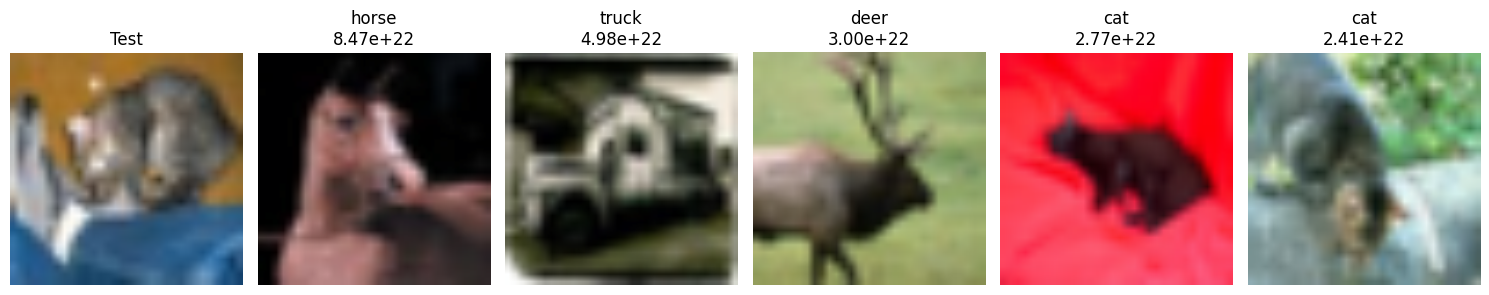

In [18]:
# Task 1 — Plot most influential training images

fig, axes = plt.subplots(1, 5 + 1, figsize=(15, 3))

test_img_raw, _ = test_dataset[test_idx]
img = test_img_raw.permute(1, 2, 0).numpy()
img = (img * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
img = np.clip(img, 0, 1)

axes[0].imshow(img)
axes[0].set_title("Test")
axes[0].axis("off")

for i, (idx, score) in enumerate(influences[:5]):
    train_img, train_label = train_dataset[idx]

    img = train_img.permute(1, 2, 0).numpy()
    img = (img * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    img = np.clip(img, 0, 1)

    axes[i + 1].imshow(img)
    axes[i + 1].set_title(f"{class_names[train_label]}\n{score:.2e}")
    axes[i + 1].axis("off")

plt.tight_layout()
plt.show()

### Counterfactuals

In [9]:
adult = fetch_openml(name="adult", version=2, as_frame=True)

X = adult.data
y = adult.target

In [10]:
X.head()

,age,workclass,fnlwgt,education,education-num,marital-status,occupation,relationship,race,sex,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States
4,18,NaN,103497,Some-college,10,Never-married,NaN,Own-child,White,Female,0,0,30,United-States


In [24]:
numerical_features = [
    "age",
    "fnlwgt",
    "education-num",
    "capital-gain",
    "capital-loss",
    "hours-per-week"
]

categorical_features = [col for col in X.columns if col not in numerical_features]

print("Numerical:", numerical_features)
print("Categorical:", categorical_features)

numeric_transformer = Pipeline(steps=[("scaler", StandardScaler())])

categorical_transformer = Pipeline(steps=[("onehot", OneHotEncoder(handle_unknown="ignore"))])

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numerical_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

Numerical: ['age', 'fnlwgt', 'education-num', 'capital-gain', 'capital-loss', 'hours-per-week']
Categorical: ['workclass', 'education', 'marital-status', 'occupation', 'relationship', 'race', 'sex', 'native-country']


**Task (0.5 points):** Train a logistic regression on the tabular dataset given.

In [25]:
# Your solution here..
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

clf = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(max_iter=1000))
])

clf.fit(X_train, y_train)

preds = clf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, preds))
print(classification_report(y_test, preds))

Accuracy: 0.8543351417750026
              precision    recall  f1-score   support

       <=50K       0.88      0.93      0.91      7431
        >50K       0.74      0.60      0.66      2338

    accuracy                           0.85      9769
   macro avg       0.81      0.77      0.79      9769
weighted avg       0.85      0.85      0.85      9769



**Task (1.5 points):** Select a negatively predicted test instance and use DiCE to generate baseline counterfactual examples. Show the feature values of the original and the counterfactual.

In [26]:
# Your solution here..
dice_data = dice_ml.Data(
    dataframe=pd.concat([X_train, y_train], axis=1),
    continuous_features=numerical_features,
    outcome_name=y.name
)

dice_model = dice_ml.Model(model=clf, backend="sklearn")

exp = dice_ml.Dice(dice_data, dice_model, method="random")

negative_idx = np.where(clf.predict(X_test) == "<=50K")[0][0]

query_instance = X_test.iloc[[negative_idx]]

cf_base = exp.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class="opposite"
)

print("Original:")
print(query_instance)

print("\nCounterfactuals:")
print(cf_base.cf_examples_list[0].final_cfs_df)

100%|██████████| 1/1 [00:00<00:00,  6.83it/s]

Original:
       age workclass  fnlwgt education  education-num      marital-status  \
40342   54   Private  115602   HS-grad              9  Married-civ-spouse   

          occupation relationship   race     sex  capital-gain  capital-loss  \
40342  Other-service         Wife  Black  Female             0             0   

       hours-per-week native-country  
40342              40  United-States  

Counterfactuals:
   age workclass   fnlwgt education  education-num      marital-status  \
0   54   Private  1130135   HS-grad              9  Married-civ-spouse   
1   54   Private   115602   HS-grad              9  Married-civ-spouse   
2   54   Private   115602   5th-6th              9  Married-civ-spouse   

      occupation relationship   race     sex  capital-gain  capital-loss  \
0  Other-service         Wife  Black  Female             0          1813   
1  Other-service         Wife  Black  Female         32441             0   
2  Other-service         Wife  Black  Female         

**Task (1.5 points):** Use DiCE's `features_to_vary` to add feasibility constraints to prevent changes to the subset of features that cannot be modified (analyse the features to determine that subset) and compare results.

In [27]:
# Your solution here..
immutable_features = [
    "age",
    "sex",
    "race",
    "native-country"
]

mutable_features = [
    col for col in X.columns if col not in immutable_features
]

cf_feasible = exp.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class="opposite",
    features_to_vary=mutable_features
)

print(cf_feasible.cf_examples_list[0].final_cfs_df)

100%|██████████| 1/1 [00:00<00:00,  3.85it/s]

   age     workclass  fnlwgt education  education-num      marital-status  \
0   54       Private  115602   HS-grad              9  Married-civ-spouse   
1   54       Private  115602   HS-grad              9  Married-civ-spouse   
2   54  Never-worked  115602   HS-grad              9  Married-civ-spouse   

      occupation relationship   race     sex  capital-gain  capital-loss  \
0  Other-service         Wife  Black  Female         34012             0   
1  Other-service         Wife  Black  Female         33725             0   
2  Other-service         Wife  Black  Female         26745             0   

   hours-per-week native-country class  
0              40  United-States  >50K  
1              40  United-States  >50K  
2              40  United-States  >50K  


**Task (1.5 points):** Add the causal constraints given and generate counterfactuals again. Compare results.

Causal Constraints:
age → education-num \
age → capital-gain \
education-num → hours-per-week \
hours-per-week → capital-gain

In [28]:
# Your solution here..
permitted_range = {
    "education-num": [
        query_instance["education-num"].values[0],
        X["education-num"].max()
    ],
    "hours-per-week": [
        query_instance["hours-per-week"].values[0],
        X["hours-per-week"].max()
    ],
    "capital-gain": [
        query_instance["capital-gain"].values[0],
        X["capital-gain"].max()
    ]
}

cf_causal = exp.generate_counterfactuals(
    query_instance,
    total_CFs=3,
    desired_class="opposite",
    features_to_vary=mutable_features,
    permitted_range=permitted_range
)

print(cf_causal.cf_examples_list[0].final_cfs_df)

100%|██████████| 1/1 [00:01<00:00,  1.16s/it]

   age workclass  fnlwgt education  education-num      marital-status  \
0   54   Private  115602   HS-grad              9  Married-civ-spouse   
1   54   Private  807099   HS-grad              9  Married-civ-spouse   
2   54   Private  115602   HS-grad              9  Married-civ-spouse   

       occupation relationship   race     sex  capital-gain  capital-loss  \
0   Other-service         Wife  Black  Female         91779             0   
1   Other-service         Wife  Black  Female             0          4168   
2  Prof-specialty         Wife  Black  Female         24509             0   

   hours-per-week native-country class  
0              40  United-States  >50K  
1              40  United-States  >50K  
2              40  United-States  >50K  


**Task (1.5 points):** Use DiCE's `kdtree` method to construct on-manifold counterfactuals. Compare all results.

In [32]:
# Your solution here..
exp_kd = dice_ml.Dice(dice_data, dice_model, method="kdtree")

cf_kdtree = exp_kd.generate_counterfactuals(
    query_instance,
    total_CFs=1,
    desired_class="opposite"
)

print(cf_kdtree.cf_examples_list[0].final_cfs_df)

100%|██████████| 1/1 [00:00<00:00,  1.03it/s]

       age workclass  fnlwgt  education  education-num      marital-status  \
21725   48   Private  115585  Bachelors             13  Married-civ-spouse   

      occupation relationship   race   sex  capital-gain  capital-loss  \
21725      Sales      Husband  White  Male             0             0   

       hours-per-week native-country class  
21725              40  United-States  >50K  


**Task (1 point):** Create a dot plot showing which numerical and categorical features changed for a selected test instance across the base, feasible, causal and manifold counterfactuals.

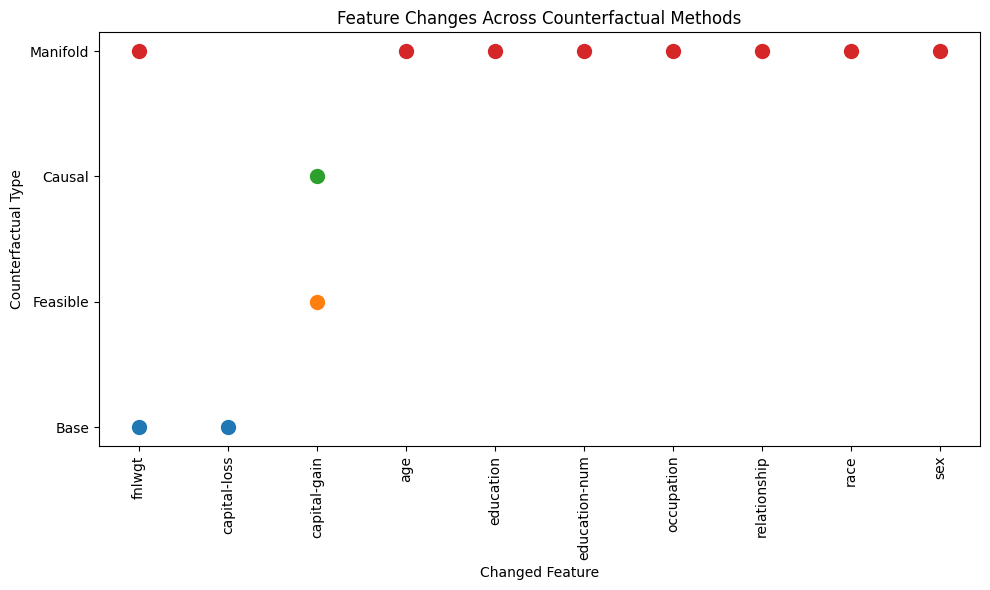

In [33]:
# Your solution here..
original = query_instance.iloc[0]

cf_dict = {
    "Base": cf_base.cf_examples_list[0].final_cfs_df.iloc[0],
    "Feasible": cf_feasible.cf_examples_list[0].final_cfs_df.iloc[0],
    "Causal": cf_causal.cf_examples_list[0].final_cfs_df.iloc[0],
    "Manifold": cf_kdtree.cf_examples_list[0].final_cfs_df.iloc[0]
}

changes = []

for method, cf in cf_dict.items():
    for col in X.columns:
        if original[col] != cf[col]:
            changes.append((method, col))

plot_df = pd.DataFrame(changes, columns=["Method", "Feature"])

plt.figure(figsize=(10, 6))

for i, method in enumerate(plot_df["Method"].unique()):
    subset = plot_df[plot_df["Method"] == method]
    plt.scatter(
        subset["Feature"],
        [i] * len(subset),
        s=100
    )

plt.yticks(range(len(plot_df["Method"].unique())), plot_df["Method"].unique())
plt.xticks(rotation=90)
plt.xlabel("Changed Feature")
plt.ylabel("Counterfactual Type")
plt.title("Feature Changes Across Counterfactual Methods")

plt.tight_layout()